<a href="https://colab.research.google.com/github/ArkanUbaidillah/DeepLearning_B_2411537001_ArkanUbaidillahWarman/blob/main/Praktikum3/2411537001_ArkanUbaidillahWarman_TugasProgram3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Individu Deep Learning Minggu 3
## Prediksi Urutan Cosine dengan RNN

Nama: Arkan Ubaidillah Warman  
NIM: 2411537001  
Kelas: B

Pada tugas ini, pola yang diprediksi diubah menjadi cosine. Model kemudian dicoba dengan beberapa `hidden_size` untuk melihat perbedaan loss dan bentuk prediksinya.

Data pada tugas individu diubah dari sinus menjadi cosine. Cara membuat sequence tetap sama, yaitu 10 nilai sebelumnya digunakan untuk memprediksi satu nilai berikutnya.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Membuat data urutan cosine
data = np.cos(np.linspace(0, 100, 1000))
seq_length = 10

def create_sequences(data, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(data, seq_length)
X = torch.FloatTensor(X).unsqueeze(-1)
y = torch.FloatTensor(y).unsqueeze(-1)

Arsitektur RNN yang dipakai tetap sama seperti praktikum utama supaya perbandingan hanya berfokus pada perubahan data dan ukuran hidden state.

In [2]:
class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, output_size=1):
        super(RNNModel, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.rnn(x)
        out = self.fc(out[:, -1, :])
        return out

Fungsi `train_rnn` dibuat agar proses training tidak perlu ditulis berulang. Fungsi ini menerima nilai `hidden_size`, melatih model selama 50 epoch, lalu mengembalikan loss dan hasil prediksi.

In [3]:
def train_rnn(hidden_size, epochs=50):
    torch.manual_seed(42)
    model = RNNModel(hidden_size=hidden_size)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    losses = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    with torch.no_grad():
        preds = model(X).numpy()

    return model, losses, preds

Model diuji dengan `hidden_size` 16, 32, dan 64. Loss akhir serta hasil prediksi dari setiap ukuran disimpan untuk dibandingkan.

In [4]:
hidden_sizes = [16, 32, 64]
results = []
predictions = {}
loss_histories = {}

for hidden_size in hidden_sizes:
    model, losses, preds = train_rnn(hidden_size)
    predictions[hidden_size] = preds
    loss_histories[hidden_size] = losses
    results.append((hidden_size, losses[-1]))
    print(f'Hidden Size {hidden_size}: Loss Akhir = {losses[-1]:.6f}')

Hidden Size 16: Loss Akhir = 0.001474
Hidden Size 32: Loss Akhir = 0.000403
Hidden Size 64: Loss Akhir = 0.000073


Kurva cosine asli dan hasil prediksi dari ketiga ukuran hidden state ditampilkan pada grafik yang sama agar perbedaannya terlihat langsung.

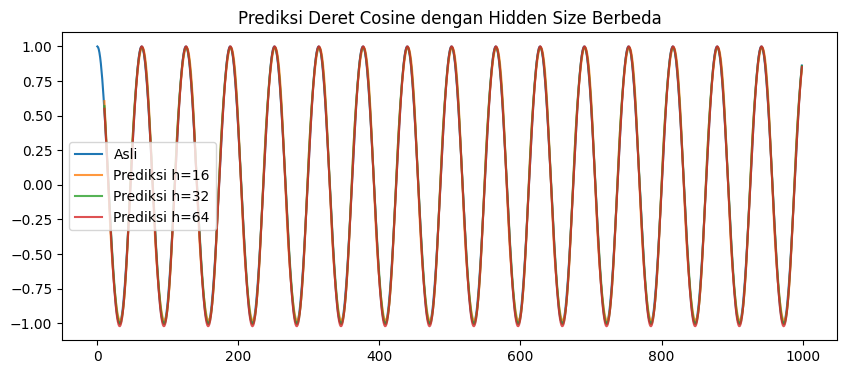

In [5]:
plt.figure(figsize=(10,4))
plt.plot(data, label='Asli')
for hidden_size in hidden_sizes:
    plt.plot(
        np.arange(seq_length, len(predictions[hidden_size]) + seq_length),
        predictions[hidden_size],
        label=f'Prediksi h={hidden_size}',
        alpha=0.8
    )
plt.legend()
plt.title('Prediksi Deret Cosine dengan Hidden Size Berbeda')
plt.show()

Hasil percobaan terakhir ditampilkan sebagai tabel sederhana yang berisi hidden size, loss akhir, bentuk prediksi, dan catatan singkat dari tiap model.

In [6]:
print(f"{'Hidden Size':<12} {'Loss Akhir':<12} {'Pola Prediksi':<18} {'Catatan'}")
print('-' * 60)

for hidden_size, loss_akhir in results:
    if hidden_size == 16:
        pola = 'halus'
        catatan = 'konvergen cepat'
    elif hidden_size == 32:
        pola = 'halus dan stabil'
        catatan = 'hasil stabil'
    else:
        pola = 'sangat halus'
        catatan = 'model lebih besar'

    print(f'{hidden_size:<12} {loss_akhir:<12.6f} {pola:<18} {catatan}')

Hidden Size  Loss Akhir   Pola Prediksi      Catatan
------------------------------------------------------------
16           0.001474     halus              konvergen cepat
32           0.000403     halus dan stabil   hasil stabil
64           0.000073     sangat halus       model lebih besar


## Kesimpulan Tugas Individu
Pada percobaan cosine ini, semua model sudah dapat mengikuti pola data. Loss akhir turun dari `hidden_size` 16 ke 32 dan kembali turun pada 64. Hasil tersebut menunjukkan bahwa penambahan neuron membantu pada percobaan ini, tetapi hasilnya tetap bergantung pada proses training dan tidak berarti ukuran yang lebih besar selalu lebih baik pada setiap kondisi.